In [2]:
import sys
print(sys.executable)

/usr/local/bin/python3


In [3]:
%pip install scikit-learn pandas matplotlib seaborn
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("Loading dataset...")
df = pd.read_csv(r"/Users/suhaas/Downloads/WA_Fn-UseC_-Telco-Customer-Churn.csv")
df = df.drop("customerID", axis=1)

Note: you may need to restart the kernel to use updated packages.
Loading dataset...


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   object 
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   object 
 3   Dependents        7043 non-null   object 
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   object 
 6   MultipleLines     7043 non-null   object 
 7   InternetService   7043 non-null   object 
 8   OnlineSecurity    7043 non-null   object 
 9   OnlineBackup      7043 non-null   object 
 10  DeviceProtection  7043 non-null   object 
 11  TechSupport       7043 non-null   object 
 12  StreamingTV       7043 non-null   object 
 13  StreamingMovies   7043 non-null   object 
 14  Contract          7043 non-null   object 
 15  PaperlessBilling  7043 non-null   object 
 16  PaymentMethod     7043 non-null   object 


In [5]:
df.isnull().sum()

gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [6]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

/var/folders/0j/y62j_vys2893kjmykkmxff500000gp/T/ipykernel_17208/194526705.py:1: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")


In [7]:
df.isnull().sum()

gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   object 
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   object 
 3   Dependents        7043 non-null   object 
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   object 
 6   MultipleLines     7043 non-null   object 
 7   InternetService   7043 non-null   object 
 8   OnlineSecurity    7043 non-null   object 
 9   OnlineBackup      7043 non-null   object 
 10  DeviceProtection  7043 non-null   object 
 11  TechSupport       7043 non-null   object 
 12  StreamingTV       7043 non-null   object 
 13  StreamingMovies   7043 non-null   object 
 14  Contract          7043 non-null   object 
 15  PaperlessBilling  7043 non-null   object 
 16  PaymentMethod     7043 non-null   object 


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/seaborn/_base.py:1447: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  self.plot_data[axis] = cat_data
/Library/Frameworks/Python.framework/Versions/3.14/lib/pytho

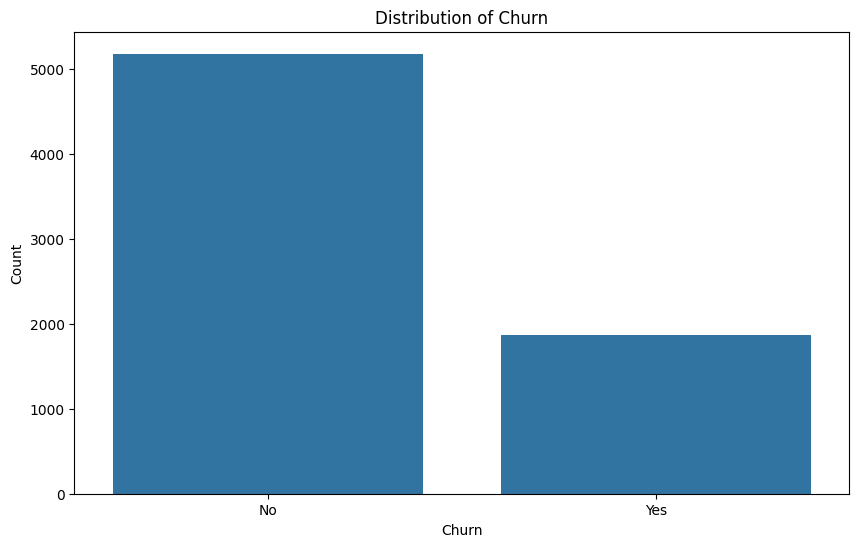

In [9]:
plt.figure(figsize=(10, 6))
sns.countplot(x="Churn", data=df)
plt.title("Distribution of Churn")
plt.xlabel("Churn")
plt.ylabel("Count")
plt.show()

In [10]:
df["Churn"].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [11]:
print("Churn Rate = {:.2f}%".format(df["Churn"].value_counts(normalize=True)["Yes"] * 100))


Churn Rate = 26.54%


In [12]:
y = df["Churn"].map({"Yes": 1, "No": 0})
X=df.drop("Churn", axis=1)

In [13]:
numeric_features = X.select_dtypes(include=["int64", "float64"]).columns
categorical_features = X.select_dtypes(include=["object"]).columns

In [14]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

In [15]:
from sklearn.preprocessing import OneHotEncoder

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

In [16]:
from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, numeric_features),
    ("cat", categorical_pipeline, categorical_features)
])

In [17]:
from sklearn.linear_model import LogisticRegression
model_log = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(
        max_iter=1000, penalty="l2", solver="lbfgs", C=1.0
    ))
])

In [18]:
from sklearn.ensemble import RandomForestClassifier
model_rf = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=100, max_depth=10, random_state=42
    ))
])

In [19]:
%pip install xgboost
%pip install --upgrade pip



Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [20]:
from xgboost import XGBClassifier
model_xgb = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", XGBClassifier(
        n_estimators=100, max_depth=5, learning_rate=0.1, random_state=42
    ))
])

In [21]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score, average_precision_score, classification_report
import numpy as np

In [22]:
skf = StratifiedKFold(n_splits=5,shuffle=True,random_state=42)

In [23]:
fold_results = []
for fold, (train_idx, val_idx) in enumerate(skf.split(X, y), 1):
#train and val idx return the index of rows in training and testing dataset respectively for each fold
#this is for logistic regression model
    print(f"\nFold: {fold}")

    X_train_fold = X.iloc[train_idx]
    y_train_fold = y.iloc[train_idx]

    X_val_fold = X.iloc[val_idx]
    y_val_fold = y.iloc[val_idx]

    model_log.fit(X_train_fold, y_train_fold)

    val_probs = model_log.predict_proba(X_val_fold)[:, 1]

    val_preds = (val_probs >= 0.54).astype(int)

    roc_auc = roc_auc_score(y_val_fold, val_probs)
    pr_auc = average_precision_score(y_val_fold, val_probs)

    report = classification_report(y_val_fold, val_preds, output_dict=True)

    recall = report["1"]["recall"]
    precision = report["1"]["precision"]

    fold_results.append({
        "fold": fold,
        "roc_auc": roc_auc,
        "pr_auc": pr_auc,
        "recall": recall,
        "precision": precision
    })

    


Fold: 1

Fold: 2

Fold: 3

Fold: 4

Fold: 5


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarnin

In [24]:
log_results = pd.DataFrame(fold_results)

log_results

,fold,roc_auc,pr_auc,recall,precision
0,1,0.854379,0.659333,0.521390,0.677083
1,2,0.845349,0.657232,0.508021,0.690909
2,3,0.863450,0.701633,0.516043,0.709559
3,4,0.825262,0.620274,0.463807,0.652830
4,5,0.836429,0.644441,0.473262,0.665414


In [25]:
print("\nMean Metrics")
print(log_results.mean())

print("\nStd Deviation")
print(log_results.std())


Mean Metrics
fold         3.000000
roc_auc      0.844974
pr_auc       0.656583
recall       0.496505
precision    0.679159
dtype: float64

Std Deviation
fold         1.581139
roc_auc      0.014929
pr_auc       0.029594
recall       0.026187
precision    0.022072
dtype: float64


In [26]:
fold_results = []
for fold, (train_idx, val_idx) in enumerate(skf.split(X, y), 1):
#train and val idx return the index of rows in training and testing dataset respectively for each fold
#this is for random forests model
    print(f"\nFold: {fold}")

    X_train_fold = X.iloc[train_idx]
    y_train_fold = y.iloc[train_idx]

    X_val_fold = X.iloc[val_idx]
    y_val_fold = y.iloc[val_idx]

    model_rf.fit(X_train_fold, y_train_fold)

    val_probs = model_rf.predict_proba(X_val_fold)[:, 1]

    val_preds = (val_probs >= 0.4).astype(int)

    roc_auc = roc_auc_score(y_val_fold, val_probs)
    pr_auc = average_precision_score(y_val_fold, val_probs)

    report = classification_report(y_val_fold, val_preds, output_dict=True)

    recall = report["1"]["recall"]
    precision = report["1"]["precision"]

    fold_results.append({
        "fold": fold,
        "roc_auc": roc_auc,
        "pr_auc": pr_auc,
        "recall": recall,
        "precision": precision
    })


Fold: 1

Fold: 2

Fold: 3

Fold: 4

Fold: 5


In [27]:
rf_results = pd.DataFrame(fold_results)

rf_results

,fold,roc_auc,pr_auc,recall,precision
0,1,0.851367,0.675000,0.649733,0.605985
1,2,0.837149,0.647043,0.671123,0.578341
2,3,0.854734,0.687225,0.673797,0.604317
3,4,0.821863,0.607351,0.595174,0.572165
4,5,0.836695,0.649665,0.622995,0.565534


In [28]:
print("\nMean Metrics")
print(rf_results.mean())

print("\nStd Deviation")
print(rf_results.std())


Mean Metrics
fold         3.000000
roc_auc      0.840362
pr_auc       0.653257
recall       0.642564
precision    0.585268
dtype: float64

Std Deviation
fold         1.581139
roc_auc      0.013168
pr_auc       0.030763
recall       0.033434
precision    0.018716
dtype: float64


In [29]:
fold_results = []
for fold, (train_idx, val_idx) in enumerate(skf.split(X, y), 1):
#train and val idx return the index of rows in training and testing dataset respectively for each fold
#this is for xgboost model
    print(f"\nFold: {fold}")

    X_train_fold = X.iloc[train_idx]
    y_train_fold = y.iloc[train_idx]

    X_val_fold = X.iloc[val_idx]
    y_val_fold = y.iloc[val_idx]

    model_xgb.fit(X_train_fold, y_train_fold)

    val_probs = model_xgb.predict_proba(X_val_fold)[:, 1]

    val_preds = (val_probs >= 0.5).astype(int)

    roc_auc = roc_auc_score(y_val_fold, val_probs)
    pr_auc = average_precision_score(y_val_fold, val_probs)

    report = classification_report(y_val_fold, val_preds, output_dict=True)

    recall = report["1"]["recall"]
    precision = report["1"]["precision"]

    fold_results.append({
        "fold": fold,
        "roc_auc": roc_auc,
        "pr_auc": pr_auc,
        "recall": recall,
        "precision": precision
    })


Fold: 1

Fold: 2

Fold: 3

Fold: 4

Fold: 5


In [30]:
xgb_results = pd.DataFrame(fold_results)

xgb_results

,fold,roc_auc,pr_auc,recall,precision
0,1,0.852860,0.670430,0.537433,0.665563
1,2,0.836234,0.644126,0.566845,0.632836
2,3,0.849423,0.677394,0.534759,0.666667
3,4,0.826909,0.617462,0.495979,0.627119
4,5,0.837885,0.646950,0.518717,0.651007


In [31]:
print("\nMean Metrics")
print(xgb_results.mean())

print("\nStd Deviation")
print(xgb_results.std())


Mean Metrics
fold         3.000000
roc_auc      0.840662
pr_auc       0.651272
recall       0.530747
precision    0.648638
dtype: float64

Std Deviation
fold         1.581139
roc_auc      0.010512
pr_auc       0.023782
recall       0.026065
precision    0.018234
dtype: float64


In [32]:
feature_names = model_log.named_steps["preprocessor"].get_feature_names_out()
coefs = model_log.named_steps["classifier"].coef_[0]

import pandas as pd

coef_df = pd.DataFrame({
    "feature": feature_names,
    "coefficient": coefs
})

coef_df = coef_df.sort_values(by="coefficient", ascending=False)

print("Top Retention Drivers[greater this lesser churn]")
coef_df.head(20)


Top Retention Drivers[greater this lesser churn]


,feature,coefficient
36,cat__Contract_Month-to-month,0.615319
3,num__TotalCharges,0.574594
16,cat__InternetService_Fiber optic,0.433411
43,cat__PaymentMethod_Electronic check,0.174300
27,cat__TechSupport_No,0.151114
18,cat__OnlineSecurity_No,0.144617
35,cat__StreamingMovies_Yes,0.133249
32,cat__StreamingTV_Yes,0.124006
0,num__SeniorCitizen,0.089907
14,cat__MultipleLines_Yes,0.050013


In [33]:
print("Top Churn Drivers[greeater this greater churn]")
coef_df.head(20)

Top Churn Drivers[greeater this greater churn]


,feature,coefficient
36,cat__Contract_Month-to-month,0.615319
3,num__TotalCharges,0.574594
16,cat__InternetService_Fiber optic,0.433411
43,cat__PaymentMethod_Electronic check,0.174300
27,cat__TechSupport_No,0.151114
18,cat__OnlineSecurity_No,0.144617
35,cat__StreamingMovies_Yes,0.133249
32,cat__StreamingTV_Yes,0.124006
0,num__SeniorCitizen,0.089907
14,cat__MultipleLines_Yes,0.050013


In [34]:
results = X.copy()
results["churn_actual"] = y
churn_pred = model_log.predict(X)
results["churn_pred"] = churn_pred
results["churn_prob"] = model_log.predict_proba(X)[:, 1]
results["Expected Value"] = results["churn_prob"] * results["MonthlyCharges"] * 12
results.head(20)
results.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 23 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   object 
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   object 
 3   Dependents        7043 non-null   object 
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   object 
 6   MultipleLines     7043 non-null   object 
 7   InternetService   7043 non-null   object 
 8   OnlineSecurity    7043 non-null   object 
 9   OnlineBackup      7043 non-null   object 
 10  DeviceProtection  7043 non-null   object 
 11  TechSupport       7043 non-null   object 
 12  StreamingTV       7043 non-null   object 
 13  StreamingMovies   7043 non-null   object 
 14  Contract          7043 non-null   object 
 15  PaperlessBilling  7043 non-null   object 
 16  PaymentMethod     7043 non-null   object 


/var/folders/0j/y62j_vys2893kjmykkmxff500000gp/T/ipykernel_17208/467235637.py:6: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  results["Expected Value"] = results["churn_prob"] * results["MonthlyCharges"] * 12


In [35]:
import numpy as np
thresholds = np.linspace(0.05, 0.8, 50)
profits = []
for threshold in thresholds:
    decision = (results["churn_prob"] >= threshold).astype(int)
    profit = ((decision) & (results["churn_actual"] == 1)) * (results["Expected Value"] - 500)
#if we retain a churning chustomer then the profit we saved is above and we add it to the profit
    profit -= ((decision) & (results["churn_actual"] == 0)) * 500
# if we retain a non churning customer then the cost we incur is above and we subtract it from the profit
    profit -= ((~decision) & (results["churn_actual"] == 1)) * results["Expected Value"]
# if we did not retain a churning customer then the loss we incur is above and we subtract it from the profit
#and someone who isnt churning we dont care about them
    profits.append(profit.sum())
best_threshold = thresholds[np.argmax(profits)]
print("Best Threshold: {:.2f} applied to the model".format(best_threshold))

Best Threshold: 0.51 applied to the model


In [36]:
ranked_results = results.sort_values(by="Expected Value", ascending=False)
ranked_results["rank"] = np.arange(1, len(ranked_results) + 1)
ranked_results.head(30)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,churn_actual,churn_pred,churn_prob,Expected Value,rank
5933,Male,1,No,No,3,Yes,Yes,Fiber optic,No,Yes,...,Month-to-month,Yes,Electronic check,105.00,294.45,1,1,0.837973,1055.845757,1
6894,Male,1,Yes,No,3,Yes,Yes,Fiber optic,No,Yes,...,Month-to-month,Yes,Electronic check,105.90,334.65,1,1,0.827036,1050.997055,2
4826,Female,1,No,No,8,Yes,Yes,Fiber optic,No,Yes,...,Month-to-month,Yes,Electronic check,105.50,829.55,1,1,0.819719,1037.763824,3
2208,Female,1,Yes,No,1,Yes,Yes,Fiber optic,No,No,...,Month-to-month,Yes,Electronic check,100.80,100.80,1,1,0.851088,1029.476201,4
261,Male,1,No,No,13,Yes,Yes,Fiber optic,No,Yes,...,Month-to-month,Yes,Electronic check,106.90,1364.30,1,1,0.794025,1018.575659,5
6365,Male,1,Yes,No,7,Yes,Yes,Fiber optic,No,No,...,Month-to-month,Yes,Electronic check,101.95,700.85,1,1,0.823743,1007.767161,6
1026,Male,1,No,No,8,Yes,Yes,Fiber optic,No,No,...,Month-to-month,Yes,Electronic check,100.60,819.40,1,1,0.833330,1005.995491,7
6482,Male,0,No,No,1,Yes,Yes,Fiber optic,No,No,...,Month-to-month,Yes,Electronic check,101.45,101.45,1,1,0.826303,1005.940904,8
2448,Female,1,No,No,14,Yes,Yes,Fiber optic,No,Yes,...,Month-to-month,Yes,Electronic check,104.85,1531.40,1,1,0.797106,1002.918963,9
905,Male,1,No,No,9,Yes,Yes,Fiber optic,No,No,...,Month-to-month,Yes,Electronic check,100.50,918.60,1,1,0.829277,1000.108007,10


In [37]:
model_log.fit(X, y)

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transforme

In [38]:
import os
print(os.path.expanduser("~"))

/Users/suhaas


In [39]:
import os
os.chdir("/Users/suhaas/Desktop/Mygit")

In [40]:
import pickle
with open("churn_model.pkl", "wb") as f:
    pickle.dump(model_log, f)

In [41]:
with open("churn_model.pkl", "rb") as f:
    loaded_model = pickle.load(f)